#### Gene hits differences analysis

In [25]:
import pandas as pd
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

In [45]:
# DrugZ TKOv3
hits_original = pd.read_csv("VINC_output_original.txt", sep = "\t")
hits_refined = pd.read_csv("VINC_output_refined.txt", sep = "\t")

# Filter hits by selecting fdr_synth < 0.1 and fdr_supp < 0.1
hits_original = hits_original[(hits_original["fdr_synth"] < 0.1) | (hits_original["fdr_supp"] < 0.1)]
hits_refined = hits_refined[(hits_refined["fdr_synth"] < 0.1) | (hits_refined["fdr_supp"] < 0.1)]

In [46]:
hits_original

,GENE,sumZ,numObs,normZ,pval_synth,rank_synth,fdr_synth,pval_supp,rank_supp,fdr_supp
0,ABCC1,-21.88,8,-7.05,8.770000e-13,1,1.580000e-08,1.000000e+00,18048,1.000000e+00
1,CCNC,-18.74,8,-6.02,8.790000e-10,2,7.930000e-06,1.000000e+00,18047,1.000000e+00
2,ITGB1,-18.07,8,-5.80,3.340000e-09,3,2.010000e-05,1.000000e+00,18046,1.000000e+00
3,CLASP1,-15.70,8,-5.01,2.660000e-07,4,1.200000e-03,1.000000e+00,18045,1.000000e+00
4,NAA30,-15.41,8,-4.92,4.330000e-07,5,1.560000e-03,1.000000e+00,18044,1.000000e+00
5,COMMD3,-13.05,6,-4.81,7.610000e-07,6,2.290000e-03,1.000000e+00,18043,1.000000e+00
6,LRRC40,-14.83,8,-4.73,1.130000e-06,7,2.920000e-03,1.000000e+00,18042,1.000000e+00
7,UBE2M,-14.29,8,-4.55,2.670000e-06,8,6.030000e-03,1.000000e+00,18041,1.000000e+00
8,UBA3,-13.96,8,-4.44,4.500000e-06,9,9.020000e-03,1.000000e+00,18040,1.000000e+00
9,POLR2A,-13.63,8,-4.33,7.440000e-06,10,1.340000e-02,1.000000e+00,18039,1.000000e+00


In [47]:
hits_refined

,GENE,sumZ,numObs,normZ,pval_synth,rank_synth,fdr_synth,pval_supp,rank_supp,fdr_supp
0,ABCC1,-22.15,8,-7.11,6.000000e-13,1,9.540000e-09,1.000000e+00,15887,1.000000e+00
1,CCNC,-16.42,6,-6.06,6.940000e-10,2,5.510000e-06,1.000000e+00,15886,1.000000e+00
2,ITGB1,-18.71,8,-5.97,1.170000e-09,3,6.210000e-06,1.000000e+00,15885,1.000000e+00
3,CLASP1,-16.00,8,-5.08,1.880000e-07,4,6.690000e-04,1.000000e+00,15884,1.000000e+00
4,NAA30,-15.93,8,-5.06,2.100000e-07,5,6.690000e-04,1.000000e+00,15883,1.000000e+00
5,COMMD3,-13.20,6,-4.83,6.790000e-07,6,1.800000e-03,1.000000e+00,15882,1.000000e+00
6,UBA3,-14.20,8,-4.49,3.540000e-06,7,8.030000e-03,1.000000e+00,15881,1.000000e+00
7,LRRC40,-12.03,6,-4.39,5.720000e-06,8,1.140000e-02,1.000000e+00,15880,1.000000e+00
8,MAPK1,-13.03,8,-4.11,2.020000e-05,9,3.570000e-02,1.000000e+00,15879,1.000000e+00
9,HECTD1,-12.85,8,-4.05,2.590000e-05,10,4.120000e-02,1.000000e+00,15878,1.000000e+00


In [48]:
# comparison between hits

def venn_diagram(df_1, df_2, name_1, name_2, colors=("red","blue"), fontsize=12):
    edges_set_1 = set(df_1['GENE'])
    edges_set_2 = set(df_2['GENE'])

    plt.figure(figsize=(5, 5))
    v = venn2([edges_set_1, edges_set_2], (str(name_1), str(name_2)), set_colors=colors)

    for text in v.set_labels:
        if text is not None:
            text.set_fontsize(fontsize)
    for text in v.subset_labels:
        if text is not None:
            text.set_fontsize(max(13, fontsize - 2))

    plt.title("Hits comparison RPE1-treated Vincristine (TKOv3 library)")
    plt.show()

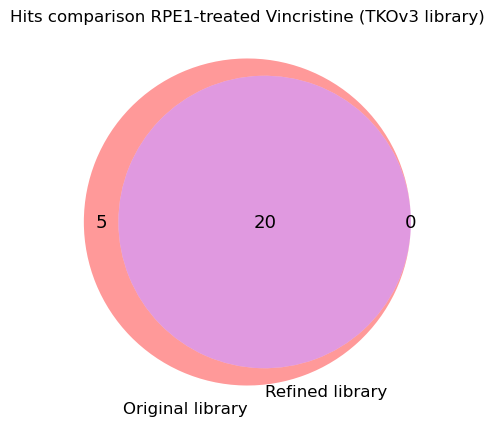

In [49]:
venn_diagram(hits_original, hits_refined, "Original library", "Refined library")

In [50]:
diff = set(hits_original["GENE"]) - set(hits_refined["GENE"])
diff

{'PAK2', 'POLR2A', 'PTEN', 'SMARCE1', 'UBE2M'}